In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [3]:
from catrace.run.run_average_timecourse import run_average_timecourse, RunAverageTimecourseParams


## Dp

2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None


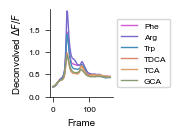

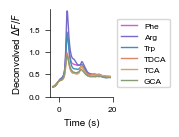

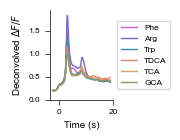

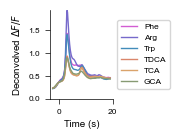

In [5]:
params = RunAverageTimecourseParams(
    config_file = '../dataset_configs/juvenile_dataset_t7.json',
    assembly_name = '',
    do_plot_per_fish = False,
    #dff = dff,
    figsize=(1.9, 1.5),
    cut_time=2.3,
    odor_colors = ['#d25dd2', '#766acb', '#428cba', '#da866b', '#daa36b', '#879a73'],
    ylim=(0, 1.95), # (0, 0.26),
    label_fontsize=7,
    tick_label_fontsize=6,
    legend_fontsize=6,
    convert_to_rate=False, # The data is already in rate
)

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name

dff, outfigs, odor_avg_naive_time, odor_avg_trained_time = run_average_timecourse(params)

In [9]:
# Save the average timecourse data to a CSV file
import os
figure_data_dir = os.path.join('../../publish_dataset\Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'figure01')
os.makedirs(save_dir, exist_ok=True)

# Only take time points between 0 and 10 seconds
odor_avg_naive_time_short = odor_avg_naive_time[(odor_avg_naive_time['time'] >= 0) & (odor_avg_naive_time['time'] <= 10)]
odor_avg_trained_time_short = odor_avg_trained_time[(odor_avg_trained_time['time'] >= 0) & (odor_avg_trained_time['time'] <= 10)]

odor_avg_naive_time_short.to_csv(os.path.join(save_dir, f'figure01d_average_traces_naive.csv'))
odor_avg_trained_time_short.to_csv(os.path.join(save_dir, f'figure01g_average_traces_trained.csv'))

In [ ]:
dff.xs('naive', level='condition', axis=1).shape
dff.shape

(2898, 43211)

In [ ]:
import numpy as np
odor_time_range = [2, 7]
frame_rate = 7.5
manifold_time_range = np.array([38, 63]) /frame_rate - params.cut_time
print(manifold_time_range)



[2.76666667 6.1       ]


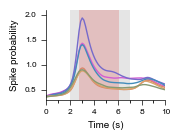

In [ ]:
import matplotlib.patches as patches

def add_time_range_rectangle(ax, time_range, color='gray', alpha=0.6, text=None, fontsize=6, text_offset=0.02):
    # Retrieve the current y-limits of the axes
    ylim = ax.get_ylim()
    
    # Create a rectangle that spans from ylim[0] to ylim[1]
    rect = patches.Rectangle(
        (time_range[0], ylim[0]),
        width=time_range[1] - time_range[0],
        height=ylim[1] - ylim[0],
        color=color,
        alpha=alpha,
        linewidth=0
    )
    ax.add_patch(rect)
    
    if text is not None:
        # Place the text at the center of the rectangle
        ax.text(
            x=time_range[0] + (time_range[1] - time_range[0]) / 2,
            y=ylim[1] + text_offset,
            s=text,
            ha='center',
            va='center',
            color=color,
            fontsize=fontsize
        )



for name in ['fig_time', 'fig_naive_time', 'fig_trained_time']:
    fig = outfigs[name]
    ax = fig.get_axes()[0]
    ax.set_xlim([0, 10])
    ax.set_ylim([0.3, 2.1])#[0.02, 0.28])
    # Set xticks with interval of 2 using multiplelocator
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Set ylabel
    ylabel = 'Spike rate (Hz)' if params.convert_to_rate else 'Spike probability'
    ax.set_ylabel(ylabel)
    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    # Add rectangle for odor presentation
    add_time_range_rectangle(ax, odor_time_range, color='gray', alpha=0.2)#, text='Odor', fontsize=6, text_offset=0.03)
    # Add rectangle for manifold presentation
    add_time_range_rectangle(ax, manifold_time_range, color='tab:red', alpha=0.2)#, text='Used for analysis', fontsize=6, text_offset=0.06)
    # Tight layout
    fig.tight_layout()


from catrace.for_paper import save_figure_for_paper
paper_fig_dir = '/tungstenfs/scratch/gfriedri/hubo/Dp_manifold/figures_for_paper'
dataset_name = 'juvenile'
save_figure_for_paper(outfigs['fig_time'], f'{dataset_name}_timecourse', paper_fig_dir)
save_figure_for_paper(outfigs['fig_naive_time'], f'{dataset_name}_timecourse_naive', paper_fig_dir)
save_figure_for_paper(outfigs['fig_trained_time'], f'{dataset_name}_timecourse_trained', paper_fig_dir)
outfigs['fig_trained_time']